# Welcome to Modal notebooks!

Write Python code and collaborate in real time. Your code runs in Modal's
**serverless cloud**, and anyone in the same workspace can join.

This notebook comes with some common Python libraries installed. Run
cells with `Shift+Enter`.

In [1]:
!git clone https://github.com/decoderesearch/SAELens

Cloning into 'SAELens'...
remote: Enumerating objects: 17092, done.
remote: Counting objects: 100% (3948/3948), done.
remote: Compressing objects: 100% (875/875), done.
remote: Total 17092 (delta 3504), reused 3102 (delta 3032), pack-reused 13144 (from 3)
Receiving objects: 100% (17092/17092), 192.93 MiB | 42.48 MiB/s, done.
Resolving deltas: 100% (10846/10846), done.


In [2]:
!nvidia-smi

Mon Feb 16 19:17:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:65:00.0 Off |                  Off |
| N/A   34C    P0             53W /  300W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [4]:
!ls

SAELens


In [1]:
%cd SAELens

/root/SAELens


In [2]:
!ls

CHANGELOG.md		       README.md     docs	     sae_lens
CLAUDE.md		       __init__.py   makefile	     scripts
Confidential_Dataset_1000.csv  benchmark     mkdocs.yml      tests
LICENSE			       codecov.yaml  pyproject.toml  tutorials


In [3]:
from __future__ import annotations

import importlib.util
import inspect
import re
import sys
from pathlib import Path
from typing import Any

import plotly.graph_objects as go
import torch
from tqdm.auto import tqdm


def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


def _find_experiment_module(start: Path) -> Path | None:
    start = start.resolve()
    candidates: list[Path] = []

    for candidate in [start, *start.parents]:
        candidates.append(candidate / "scripts" / "medical_reasoning_sae_experiment.py")

    for child in start.iterdir() if start.exists() else []:
        if child.is_dir():
            candidates.append(child / "scripts" / "medical_reasoning_sae_experiment.py")

    for module_path in candidates:
        if module_path.exists():
            return module_path
    return None


workspace = Path.cwd()
repo_root = _find_repo_root(workspace)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

module_path = _find_experiment_module(workspace)
if module_path is None:
    raise ModuleNotFoundError(
        "Could not find scripts/medical_reasoning_sae_experiment.py from current working directory. "
        "Ensure the SAELens repository is mounted (with the scripts folder) or copy that file next to your notebook runtime."
    )

spec = importlib.util.spec_from_file_location("medical_reasoning_sae_experiment", module_path)
if spec is None or spec.loader is None:
    raise ImportError(f"Failed to create module spec for {module_path}")

experiment_module = importlib.util.module_from_spec(spec)
sys.modules["medical_reasoning_sae_experiment"] = experiment_module
spec.loader.exec_module(experiment_module)

DecodeConfig = experiment_module.DecodeConfig
ExampleRunRecord = experiment_module.ExampleRunRecord
ModelRuntime = experiment_module.ModelRuntime
QAExample = experiment_module.QAExample
build_default_specs = experiment_module.build_default_specs
compute_delta = experiment_module.compute_delta
cot_prompt = experiment_module.cot_prompt
direct_prompt = experiment_module.direct_prompt
extract_first_token_features = experiment_module.extract_first_token_features
load_confidential_dataset = experiment_module.load_confidential_dataset
load_model_runtime = experiment_module.load_model_runtime
paired_permutation_test = experiment_module.paired_permutation_test
parse_answer_letter = experiment_module.parse_answer_letter
run_single_condition = experiment_module.run_single_condition
save_json = experiment_module.save_json
save_jsonl = experiment_module.save_jsonl
scaffold_prompt = experiment_module.scaffold_prompt
self_revision_prompt = experiment_module.self_revision_prompt
summarize_records = experiment_module.summarize_records
topk_reasoning_features = experiment_module.topk_reasoning_features

# Cloud compatibility hotfix: if older helper module is loaded, patch DeepSeek runtime loading.
source_text = inspect.getsource(load_model_runtime)
needs_deepseek_hotfix = "hf_model=generation_model" not in source_text

if needs_deepseek_hotfix:
    from sae_lens import SAE
    from sae_lens.analysis.hooked_sae_transformer import HookedSAETransformer
    from transformers import AutoModelForCausalLM, AutoTokenizer

    def _resolve_torch_dtype(dtype: str) -> torch.dtype:
        if dtype == "float16":
            return torch.float16
        if dtype == "bfloat16":
            return torch.bfloat16
        return torch.float32

    _orig_load_model_runtime = load_model_runtime

    def load_model_runtime(spec: Any) -> Any:
        if spec.hf_model_name != "deepseek-ai/DeepSeek-R1-Distill-Llama-8B":
            return _orig_load_model_runtime(spec)

        tokenizer = AutoTokenizer.from_pretrained(spec.hf_model_name, **spec.tokenizer_kwargs)
        if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
            tokenizer.pad_token = tokenizer.eos_token

        generation_model = AutoModelForCausalLM.from_pretrained(
            spec.hf_model_name,
            dtype=_resolve_torch_dtype(spec.dtype),
            **spec.hf_model_kwargs,
        ).to(spec.device)
        generation_model.eval()

        cache_model = HookedSAETransformer.from_pretrained_no_processing(
            "meta-llama/Llama-3.1-8B",
            hf_model=generation_model,
            device=spec.device,
        )

        sae = SAE.from_pretrained(
            release=spec.sae_release,
            sae_id=spec.sae_id,
            device=spec.device,
            dtype=spec.dtype,
        )
        sae.eval()

        return ModelRuntime(spec, generation_model, tokenizer, cache_model, sae)

print(f"Kernel cwd: {workspace}")
print(f"Repo root: {repo_root}")
print(f"Loaded experiment module from: {module_path}")
if needs_deepseek_hotfix:
    print("Applied DeepSeek cloud compatibility hotfix for load_model_runtime.")

Kernel cwd: /root/SAELens
Repo root: /root/SAELens
Loaded experiment module from: /root/SAELens/scripts/medical_reasoning_sae_experiment.py


In [9]:
%uv pip install sae-lens

Using Python 3.12.6 environment at: /usr/local
Resolved 110 packages in 221ms
Building py2store==0.1.22
Building py2store==0.1.22
⠙ Preparing packages... (0/10)
Building py2store==0.1.22
⠙ Preparing packages... (0/10)
Building py2store==0.1.22
⠙ Preparing packages... (0/10)
plotly-express ------------------------------     0 B/2.84 KiB
Building py2store==0.1.22
⠙ Preparing packages... (0/10)
plotly-express ------------------------------ 2.84 KiB/2.84 KiB
Building py2store==0.1.22
⠙ Preparing packages... (0/10)
plotly-express ------------------------------ 2.84 KiB/2.84 KiB
babe       ------------------------------     0 B/6.71 KiB
Building py2store==0.1.22
⠙ Preparing packages... (0/10)
plotly-express ------------------------------ 2.84 KiB/2.84 KiB
babe       ------------------------------ 6.71 KiB/6.71 KiB
Building py2store==0.1.22
⠙ Preparing packages... (0/10)
plotly-express ------------------------------ 2.84 KiB/2.84 KiB
babe       ------------------------------ 6.71 KiB/6.71 KiB

In [8]:
%uv pip install einops transformer-lens simple-parsing 

Using Python 3.12.6 environment at: /usr/local
Resolved 92 packages in 293ms
Building transformers-stream-generator==0.0.5
Building transformers-stream-generator==0.0.5
⠙ Preparing packages... (0/23)
Building transformers-stream-generator==0.0.5
⠙ Preparing packages... (0/23)
smmap      ------------------------------     0 B/23.73 KiB
Building transformers-stream-generator==0.0.5
⠙ Preparing packages... (0/23)
smmap      ------------------------------     0 B/23.73 KiB
gitdb      ------------------------------     0 B/61.32 KiB
Building transformers-stream-generator==0.0.5
⠙ Preparing packages... (0/23)
smmap      ------------------------------     0 B/23.73 KiB
docstring-parser ------------------------------     0 B/36.03 KiB
gitdb      ------------------------------     0 B/61.32 KiB
Building transformers-stream-generator==0.0.5
⠙ Preparing packages... (0/23)
smmap      ------------------------------     0 B/23.73 KiB
docstring-parser ------------------------------     0 B/36.03 KiB


In [12]:
%uv pip install --upgrade typing-extensions

Using Python 3.12.6 environment at: /usr/local
Resolved 1 package in 13ms
Audited 1 package in 0.09ms
Note: you may need to restart the kernel to use updated packages.


In [4]:
# ---- Configuration ----
device = "cuda" if torch.cuda.is_available() else "cpu"
pilot_size = 200
run_full_after_pilot = False
inference_batch_size = 8 if device == "cuda" else 2

csv_path = workspace / "Confidential_Dataset_1000.csv"
out_root = workspace / "outputs" / "medical_reasoning_sae"
out_root.mkdir(parents=True, exist_ok=True)

# GPU performance + precision diagnostics
if device == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

    gpu_name = torch.cuda.get_device_name(0)
    total_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    capability = torch.cuda.get_device_capability(0)
    bf16_supported = bool(getattr(torch.cuda, "is_bf16_supported", lambda: False)())

    # Prefer bf16 when supported; otherwise use fp16 for speed.
    if bf16_supported:
        compute_dtype = "bfloat16"
    else:
        compute_dtype = "float16"

    print(f"CUDA enabled on: {gpu_name} ({total_gb:.1f} GB), capability={capability}")
    print(f"Selected compute dtype: {compute_dtype} (bf16_supported={bf16_supported})")
    print(f"Inference batch size: {inference_batch_size}")
else:
    compute_dtype = "float32"
    print("CUDA not available; using float32 on CPU (slowest mode).")

# Conservative defaults for deterministic behavior.
decode_cfg = DecodeConfig(
    max_new_tokens=256,
    do_sample=False,
    temperature=0.0,
    top_p=1.0,
)

# Preconfigured specs for your two-model setup.
deepseek_spec, gemma_spec = build_default_specs(device=device)

# Override dtype based on detected GPU precision support.
deepseek_spec.dtype = compute_dtype
gemma_spec.dtype = compute_dtype

deepseek_spec.hf_model_kwargs.update({"trust_remote_code": True})
gemma_spec.hf_model_kwargs.update({"trust_remote_code": True})

print(deepseek_spec)
print(gemma_spec)
print(f"Output directory: {out_root}")

CUDA enabled on: NVIDIA A100 80GB PCIe (79.3 GB), capability=(8, 0)
Selected compute dtype: bfloat16 (bf16_supported=True)
Inference batch size: 8
ModelSpec(name='deepseek_r1_distill_llama8b', hf_model_name='deepseek-ai/DeepSeek-R1-Distill-Llama-8B', sae_release='deepseek-r1-distill-llama-8b-qresearch', sae_id='blocks.19.hook_resid_post', tlens_model_name='meta-llama/Llama-3.1-8B', device='cuda', dtype='bfloat16', hf_model_kwargs={'trust_remote_code': True}, tokenizer_kwargs={})
ModelSpec(name='gemma_3_4b_it', hf_model_name='google/gemma-3-4b-it', sae_release='gemma-scope-2-4b-it-res', sae_id='layer_17_width_16k_l0_medium', tlens_model_name=None, device='cuda', dtype='bfloat16', hf_model_kwargs={'trust_remote_code': True}, tokenizer_kwargs={})
Output directory: /root/SAELens/outputs/medical_reasoning_sae


In [5]:
# ---- Data load ----
examples = load_confidential_dataset(csv_path)
print(f"Loaded examples: {len(examples)}")

pilot_examples = examples[:pilot_size]
run_examples = pilot_examples
print(f"Run set size: {len(run_examples)}")

Loaded examples: 1000
Run set size: 200


In [ ]:
!hf auth login --token YOUR_HF_TOKEN

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: write).
The token `LLM_works` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `LLM_works`


In [7]:
# ---- Model + SAE load (can take a while) ----
try:
    deepseek_runtime: ModelRuntime = load_model_runtime(deepseek_spec)
    gemma_runtime: ModelRuntime = load_model_runtime(gemma_spec)
except ModuleNotFoundError as error:
    if "transformer-lens>=3.0.0b0" in str(error):
        print("Gemma-3 bridge dependency is missing.")
        print("Run this once in a notebook cell, then restart kernel:")
        print("%pip install 'transformer-lens>=3.0.0b0'")
    raise
except ValueError as error:
    error_text = str(error)
    if "TransformerBridgeConfig.__init__" in error_text or "Failed to build cache model for Gemma-3" in error_text:
        print("Gemma-3 cache-model loading failed due TransformerLens version mismatch.")
        print("Fix steps:")
        print("1) Re-run Cell 2 to reload updated helper module.")
        print("2) If still failing, upgrade TransformerLens and restart kernel:")
        print("   %pip install -U transformer-lens")
    raise

# Gemma SAE numerical stability: fp16 SAE can overflow on some GPUs.
if device == "cuda" and gemma_spec.dtype == "float16":
    gemma_runtime.sae = gemma_runtime.sae.to(dtype=torch.float32)
    print("Promoted Gemma SAE to float32 for stability (model generation remains float16).")

print("Loaded runtimes:")
print(f"- {deepseek_runtime.spec.name}")
print(f"- {gemma_runtime.spec.name}")

# Explicit device checks so we know generation really sits on GPU
def _model_device(model: torch.nn.Module) -> str:
    return str(next(model.parameters()).device)

print(f"DeepSeek generation model device: {_model_device(deepseek_runtime.generation_model)}")
print(f"Gemma generation model device: {_model_device(gemma_runtime.generation_model)}")
print(f"Gemma SAE dtype: {next(gemma_runtime.sae.parameters()).dtype}")
if device == "cuda":
    print(f"CUDA memory allocated: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
    print(f"CUDA memory reserved:  {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Loaded pretrained model google/gemma-3-4b-it into HookedTransformer


config.json:   0%|          | 0.00/247 [00:00<?, ?B/s]

resid_post/layer_17_width_16k_l0_medium/(…):   0%|          | 0.00/336M [00:00<?, ?B/s]

Loaded runtimes:
- deepseek_r1_distill_llama8b
- gemma_3_4b_it
DeepSeek generation model device: cuda:0
Gemma generation model device: cuda:0
Gemma SAE dtype: torch.bfloat16
CUDA memory allocated: 73.85 GB
CUDA memory reserved:  74.14 GB


In [9]:
%uv pip install 'transformer-lens>=3.0.0b0'

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 48ms
Note: you may need to restart the kernel to use updated packages.


In [8]:
# ---- Utility for per-model direct vs CoT collection ----
def _run_batch_condition(
    runtime: ModelRuntime,
    examples_batch: list[QAExample],
    prompts: list[str],
    decode: DecodeConfig,
    condition: str,
) -> tuple[list[ExampleRunRecord], list[torch.Tensor | None]]:
    tokenizer = runtime.generation_tokenizer
    model = runtime.generation_model

    encoded = tokenizer(prompts, return_tensors="pt", padding=True)
    input_ids = encoded["input_ids"].to(runtime.spec.device)
    attn_mask = encoded["attention_mask"].to(runtime.spec.device)

    generate_kwargs: dict[str, Any] = {
        "input_ids": input_ids,
        "attention_mask": attn_mask,
        "max_new_tokens": decode.max_new_tokens,
        "do_sample": decode.do_sample,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id,
    }
    if decode.do_sample:
        generate_kwargs["temperature"] = decode.temperature
        generate_kwargs["top_p"] = decode.top_p

    with torch.inference_mode():
        output_ids = model.generate(**generate_kwargs)

    prompt_lengths = attn_mask.sum(dim=1).tolist()
    records: list[ExampleRunRecord] = []
    features: list[torch.Tensor | None] = []

    for idx, ex in enumerate(examples_batch):
        pl = int(prompt_lengths[idx])
        generated_ids = output_ids[idx, pl:]
        first_token = int(generated_ids[0].item()) if generated_ids.numel() > 0 else None
        text = tokenizer.decode(generated_ids, skip_special_tokens=True)

        parsed = parse_answer_letter(text)
        is_correct = None if parsed is None else parsed == ex.answer_key

        feat = None
        if first_token is not None:
            feat = extract_first_token_features(runtime, prompts[idx], first_token)
            if feat is not None:
                feat = torch.nan_to_num(feat, nan=0.0, posinf=1e4, neginf=-1e4)

        rec = ExampleRunRecord(
            question_id=ex.question_id,
            model_name=runtime.spec.name,
            condition=condition,
            answer_text=text,
            parsed_answer=parsed,
            is_correct=is_correct,
            first_token_id=first_token,
            reasoning_text=None,
        )
        records.append(rec)
        features.append(feat)

    return records, features


def collect_direct_cot(
    runtime: ModelRuntime,
    examples_subset: list[QAExample],
    decode: DecodeConfig,
    batch_size: int,
) -> tuple[
    list[ExampleRunRecord],
    list[ExampleRunRecord],
    list[torch.Tensor],
    list[torch.Tensor],
    torch.Tensor,
    list[dict[str, float | int]],
]:
    direct_records: list[ExampleRunRecord] = []
    cot_records: list[ExampleRunRecord] = []
    direct_features: list[torch.Tensor] = []
    cot_features: list[torch.Tensor] = []

    progress = tqdm(
        range(0, len(examples_subset), batch_size),
        desc=f"{runtime.spec.name} direct+cot",
        unit="batch",
        dynamic_ncols=True,
    )

    for start_idx in progress:
        examples_batch = examples_subset[start_idx : start_idx + batch_size]
        direct_prompts = [direct_prompt(ex) for ex in examples_batch]
        cot_prompts = [cot_prompt(ex) for ex in examples_batch]

        d_records, d_feats = _run_batch_condition(
            runtime=runtime,
            examples_batch=examples_batch,
            prompts=direct_prompts,
            decode=decode,
            condition="direct",
        )
        c_records, c_feats = _run_batch_condition(
            runtime=runtime,
            examples_batch=examples_batch,
            prompts=cot_prompts,
            decode=decode,
            condition="cot",
        )

        direct_records.extend(d_records)
        cot_records.extend(c_records)

        for d_feat, c_feat in zip(d_feats, c_feats, strict=False):
            if d_feat is not None and c_feat is not None:
                direct_features.append(d_feat)
                cot_features.append(c_feat)

        if len(direct_records) % 20 == 0:
            progress.set_postfix(
                done=len(direct_records),
                valid_pairs=len(direct_features),
                direct_acc=f"{_accuracy(direct_records):.3f}",
                cot_acc=f"{_accuracy(cot_records):.3f}",
            )

    delta = compute_delta(cot_features, direct_features)
    top_features = topk_reasoning_features(delta, k=10)
    return direct_records, cot_records, direct_features, cot_features, delta, top_features


def _accuracy(records: list[ExampleRunRecord]) -> float:
    valid = [record for record in records if record.is_correct is not None]
    if not valid:
        return float("nan")
    return sum(1 for record in valid if record.is_correct) / len(valid)


def plot_condition_accuracies(
    labels: list[str],
    record_groups: list[list[ExampleRunRecord]],
    title: str,
):
    y_vals = [_accuracy(group) for group in record_groups]
    fig = go.Figure(
        data=[
            go.Bar(
                x=labels,
                y=y_vals,
                text=[f"{v:.3f}" if v == v else "nan" for v in y_vals],
                textposition="outside",
            )
        ]
    )
    fig.update_layout(
        title=title,
        yaxis_title="Accuracy",
        xaxis_title="Condition",
        yaxis_range=[0, 1],
        template="plotly_white",
        height=450,
    )
    fig.show()


def plot_top_feature_deltas(
    top_features: list[dict[str, float | int]],
    model_name: str,
    top_k: int = 10,
):
    top_rows = top_features[:top_k]
    x_labels = [str(int(row["feature_index"])) for row in top_rows]
    y_vals = [float(row["signed_delta"]) for row in top_rows]
    colors = ["#1f77b4" if val >= 0 else "#d62728" for val in y_vals]

    fig = go.Figure(
        data=[
            go.Bar(
                x=x_labels,
                y=y_vals,
                marker_color=colors,
                text=[f"{v:.4f}" for v in y_vals],
                textposition="outside",
            )
        ]
    )
    fig.update_layout(
        title=f"{model_name}: Top {top_k} Differential SAE Features (CoT - Direct)",
        xaxis_title="Feature Index",
        yaxis_title="Signed Δ activation",
        template="plotly_white",
        height=480,
    )
    fig.show()


def plot_scaffold_activation_scatter(
    direct_vals: list[float],
    scaffold_vals: list[float],
    feature_idx: int,
):
    n = min(len(direct_vals), len(scaffold_vals))
    if n == 0:
        print("No activation pairs available for scaffold scatter plot.")
        return

    min_val = min(min(direct_vals), min(scaffold_vals))
    max_val = max(max(direct_vals), max(scaffold_vals))

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=direct_vals,
            y=scaffold_vals,
            mode="markers",
            marker={"size": 8, "opacity": 0.7},
            name="Examples",
        )
    )
    fig.add_trace(
        go.Scatter(
            x=[min_val, max_val],
            y=[min_val, max_val],
            mode="lines",
            line={"dash": "dash", "color": "black"},
            name="y=x",
        )
    )
    fig.update_layout(
        title=f"Gemma Feature {feature_idx}: Direct vs Scaffolded Activation",
        xaxis_title="Direct activation",
        yaxis_title="Scaffolded activation",
        template="plotly_white",
        height=520,
    )
    fig.show()


def plot_scaffold_delta_hist(
    direct_vals: list[float],
    scaffold_vals: list[float],
    feature_idx: int,
):
    n = min(len(direct_vals), len(scaffold_vals))
    if n == 0:
        print("No activation pairs available for delta histogram.")
        return

    deltas = [scaffold_vals[i] - direct_vals[i] for i in range(n)]
    fig = go.Figure(
        data=[
            go.Histogram(
                x=deltas,
                nbinsx=40,
            )
        ]
    )
    fig.update_layout(
        title=f"Activation Shift Distribution (Scaffolded - Direct), Feature {feature_idx}",
        xaxis_title="Activation delta",
        yaxis_title="Count",
        template="plotly_white",
        height=420,
    )
    fig.show()

In [9]:
# ---- Phase 1: Differential discovery per model (Gemma first, then DeepSeek) ----
def _collect_direct_cot_compat(
    runtime: ModelRuntime,
    examples_subset: list[QAExample],
    decode: DecodeConfig,
    batch_size: int,
):
    collector: Any = collect_direct_cot
    params = inspect.signature(collector).parameters

    if "batch_size" in params:
        return collector(
            runtime,
            examples_subset,
            decode,
            batch_size=batch_size,
        )

    print(
        "Detected older in-kernel collect_direct_cot signature; "
        "falling back to non-batched mode for this run. "
        "Re-run Cell 6 to enable batching."
    )
    return collector(runtime, examples_subset, decode)

(
    gemma_direct_records,
    gemma_cot_records,
    gemma_direct_features,
    gemma_cot_features,
    gemma_delta,
    gemma_top_features,
) = _collect_direct_cot_compat(
    gemma_runtime,
    run_examples,
    decode_cfg,
    batch_size=inference_batch_size,
)

(
    deepseek_direct_records,
    deepseek_cot_records,
    deepseek_direct_features,
    deepseek_cot_features,
    deepseek_delta,
    deepseek_top_features,
) = _collect_direct_cot_compat(
    deepseek_runtime,
    run_examples,
    decode_cfg,
    batch_size=inference_batch_size,
)

print("Gemma summary:", summarize_records(gemma_direct_records))
print("DeepSeek summary:", summarize_records(deepseek_direct_records))

print("Top Gemma reasoning features:")
for row in gemma_top_features:
    print(row)

print("Top DeepSeek reasoning features:")
for row in deepseek_top_features:
    print(row)

gemma_3_4b_it direct+cot:   0%|                                                      | 0/25 [00:00<?, ?batch/s…

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


deepseek_r1_distill_llama8b direct+cot:   0%|                                        | 0/25 [00:00<?, ?batch/s…

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Gemma summary: {'total': 200, 'valid_answer_count': 200, 'accuracy': 0.17}
DeepSeek summary: {'total': 200, 'valid_answer_count': 200, 'accuracy': 0.215}
Top Gemma reasoning features:
{'feature_index': 534, 'abs_delta': 335.9000244140625, 'signed_delta': 335.9000244140625}
{'feature_index': 4813, 'abs_delta': 275.7599792480469, 'signed_delta': 275.7599792480469}
{'feature_index': 5015, 'abs_delta': 249.40501403808594, 'signed_delta': 249.40501403808594}
{'feature_index': 712, 'abs_delta': 226.58999633789062, 'signed_delta': -226.58999633789062}
{'feature_index': 96, 'abs_delta': 199.4399871826172, 'signed_delta': -199.4399871826172}
{'feature_index': 486, 'abs_delta': 154.60000610351562, 'signed_delta': 154.60000610351562}
{'feature_index': 441, 'abs_delta': 149.2650146484375, 'signed_delta': -149.2650146484375}
{'feature_index': 328, 'abs_delta': 124.8699951171875, 'signed_delta': 124.8699951171875}
{'feature_index': 447, 'abs_delta': 114.40499877929688, 'signed_delta': -114.404998779

In [10]:
# ---- Visuals: Phase 1 discovery ----
plot_condition_accuracies(
    labels=["Gemma Direct", "Gemma CoT", "DeepSeek Direct", "DeepSeek CoT"],
    record_groups=[
        gemma_direct_records,
        gemma_cot_records,
        deepseek_direct_records,
        deepseek_cot_records,
    ],
    title="Direct vs CoT Accuracy by Model",
)

plot_top_feature_deltas(gemma_top_features, "Gemma", top_k=10)
plot_top_feature_deltas(deepseek_top_features, "DeepSeek", top_k=10)

In [12]:
# ---- Phase 2: DeepSeek behavior + Gemma scaffold evaluation ----
behavior_records: list[ExampleRunRecord] = []
gemma_scaffold_records: list[ExampleRunRecord] = []
gemma_direct_records_for_subset: list[ExampleRunRecord] = []

# Pick primary reasoning features from Phase 1.
gemma_primary_feature = int(gemma_top_features[0]["feature_index"])
deepseek_primary_feature = int(deepseek_top_features[0]["feature_index"])

activation_direct: list[float] = []
activation_scaffold: list[float] = []
flip_case_count = 0
deepseek_parse_fail_count = 0

# Hypothesis-1 tracking arrays (DeepSeek feature activation split by correctness)
ds_direct_wrong_acts: list[float] = []
ds_direct_correct_acts: list[float] = []
ds_cot_wrong_acts: list[float] = []
ds_cot_correct_acts: list[float] = []

progress = tqdm(
    run_examples,
    desc="Cross-model scaffold eval",
    unit="example",
    dynamic_ncols=True,
)

for ex in progress:
    # DeepSeek direct
    ds_direct_record, ds_direct_feat = run_single_condition(
        runtime=deepseek_runtime,
        example=ex,
        prompt=direct_prompt(ex),
        decode_cfg=decode_cfg,
        condition="deepseek_direct",
    )

    # DeepSeek CoT
    ds_cot_record, ds_cot_feat = run_single_condition(
        runtime=deepseek_runtime,
        example=ex,
        prompt=cot_prompt(ex),
        decode_cfg=decode_cfg,
        condition="deepseek_cot",
    )

    # DeepSeek self-revision seeded from CoT output
    ds_selfrev_record, _ = run_single_condition(
        runtime=deepseek_runtime,
        example=ex,
        prompt=self_revision_prompt(
            ex,
            prior_reasoning=ds_cot_record.answer_text,
            prior_answer=(ds_cot_record.parsed_answer or "UNKNOWN"),
        ),
        decode_cfg=decode_cfg,
        condition="deepseek_self_revision",
    )

    behavior_records.extend([ds_direct_record, ds_cot_record, ds_selfrev_record])

    if ds_direct_feat is not None and ds_direct_record.is_correct is not None:
        val = float(ds_direct_feat[deepseek_primary_feature].item())
        if ds_direct_record.is_correct:
            ds_direct_correct_acts.append(val)
        else:
            ds_direct_wrong_acts.append(val)

    if ds_cot_feat is not None and ds_cot_record.is_correct is not None:
        val = float(ds_cot_feat[deepseek_primary_feature].item())
        if ds_cot_record.is_correct:
            ds_cot_correct_acts.append(val)
        else:
            ds_cot_wrong_acts.append(val)

    # We only keep examples where DeepSeek direct parsed cleanly and is explicitly wrong.
    if ds_direct_record.is_correct is None:
        deepseek_parse_fail_count += 1
        if len(behavior_records) % 30 == 0:
            progress.set_postfix(
                ds_wrong_subset=len(gemma_direct_records_for_subset),
                flips=flip_case_count,
                ds_parse_fail=deepseek_parse_fail_count,
            )
        continue

    if ds_direct_record.is_correct is not False:
        if len(behavior_records) % 30 == 0:
            progress.set_postfix(
                ds_wrong_subset=len(gemma_direct_records_for_subset),
                flips=flip_case_count,
                ds_parse_fail=deepseek_parse_fail_count,
            )
        continue

    # Gemma direct
    gm_direct_record, gm_direct_feat = run_single_condition(
        runtime=gemma_runtime,
        example=ex,
        prompt=direct_prompt(ex),
        decode_cfg=decode_cfg,
        condition="gemma_direct_on_ds_wrong",
    )

    # Gemma scaffolded with DeepSeek CoT text
    gm_scaffold_record, gm_scaffold_feat = run_single_condition(
        runtime=gemma_runtime,
        example=ex,
        prompt=scaffold_prompt(ex, ds_cot_record.answer_text),
        decode_cfg=decode_cfg,
        condition="gemma_scaffolded_with_deepseek_reasoning",
        reasoning_text=ds_cot_record.answer_text,
    )

    gemma_direct_records_for_subset.append(gm_direct_record)
    gemma_scaffold_records.append(gm_scaffold_record)

    if gm_direct_feat is not None and gm_scaffold_feat is not None:
        activation_direct.append(float(gm_direct_feat[gemma_primary_feature].item()))
        activation_scaffold.append(float(gm_scaffold_feat[gemma_primary_feature].item()))

    if gm_direct_record.is_correct is False and gm_scaffold_record.is_correct is True:
        flip_case_count += 1

    if len(gemma_direct_records_for_subset) % 10 == 0:
        progress.set_postfix(
            ds_wrong_subset=len(gemma_direct_records_for_subset),
            flips=flip_case_count,
            paired_acts=len(activation_direct),
            ds_parse_fail=deepseek_parse_fail_count,
        )

print(f"DeepSeek direct parse-fail count: {deepseek_parse_fail_count}")
print(f"DeepSeek direct-wrong subset size: {len(gemma_direct_records_for_subset)}")
print(f"Gemma direct->scaffold corrected flips: {flip_case_count}")
print(f"H1 tracking sizes | DS direct wrong/correct: {len(ds_direct_wrong_acts)}/{len(ds_direct_correct_acts)}")
print(f"H1 tracking sizes | DS CoT wrong/correct: {len(ds_cot_wrong_acts)}/{len(ds_cot_correct_acts)}")

Cross-model scaffold eval:   0%|                                                  | 0/200 [00:00<?, ?example/s…

DeepSeek direct parse-fail count: 0
DeepSeek direct-wrong subset size: 158
Gemma direct->scaffold corrected flips: 23
H1 tracking sizes | DS direct wrong/correct: 158/42
H1 tracking sizes | DS CoT wrong/correct: 173/27


In [13]:
# ---- Phase 3: Statistical test + artifact export ----
stat_result = None
if activation_direct and activation_scaffold:
    stat_result = paired_permutation_test(activation_scaffold, activation_direct)
    print("Paired permutation test on Gemma primary reasoning feature:")
    print(stat_result)
else:
    print("No paired activations available yet; check feature extraction logs.")

manifest: dict[str, Any] = {
    "run_examples": len(run_examples),
    "pilot_mode": not run_full_after_pilot,
    "device": device,
    "deepseek_spec": {
        "model": deepseek_spec.hf_model_name,
        "sae_release": deepseek_spec.sae_release,
        "sae_id": deepseek_spec.sae_id,
    },
    "gemma_spec": {
        "model": gemma_spec.hf_model_name,
        "sae_release": gemma_spec.sae_release,
        "sae_id": gemma_spec.sae_id,
    },
    "deepseek_top_features": deepseek_top_features,
    "gemma_top_features": gemma_top_features,
    "gemma_primary_feature": int(gemma_primary_feature),
    "flip_case_count": int(flip_case_count),
    "stats": stat_result,
    "deepseek_direct_summary": summarize_records(
        [r for r in behavior_records if r.condition == "deepseek_direct"]
    ),
    "deepseek_cot_summary": summarize_records(
        [r for r in behavior_records if r.condition == "deepseek_cot"]
    ),
    "deepseek_selfrev_summary": summarize_records(
        [r for r in behavior_records if r.condition == "deepseek_self_revision"]
    ),
    "gemma_direct_on_ds_wrong_summary": summarize_records(gemma_direct_records_for_subset),
    "gemma_scaffolded_summary": summarize_records(gemma_scaffold_records),
}

save_json(out_root / "manifest.json", manifest)
save_jsonl(out_root / "deepseek_behavior_records.jsonl", behavior_records)
save_jsonl(out_root / "deepseek_discovery_direct.jsonl", deepseek_direct_records)
save_jsonl(out_root / "deepseek_discovery_cot.jsonl", deepseek_cot_records)
save_jsonl(out_root / "gemma_discovery_direct.jsonl", gemma_direct_records)
save_jsonl(out_root / "gemma_discovery_cot.jsonl", gemma_cot_records)
save_jsonl(out_root / "gemma_direct_on_ds_wrong.jsonl", gemma_direct_records_for_subset)
save_jsonl(out_root / "gemma_scaffolded_on_ds_wrong.jsonl", gemma_scaffold_records)

print(f"Saved artifacts under: {out_root}")

Paired permutation test on Gemma primary reasoning feature:
{'mean_delta': 127.17721518987342, 'p_value': 0.0001999600079984003, 'n': 158.0}
Saved artifacts under: /root/SAELens/outputs/medical_reasoning_sae


In [14]:
# ---- Visuals: scaffold effect ----
plot_condition_accuracies(
    labels=[
        "DeepSeek Direct",
        "DeepSeek CoT",
        "DeepSeek Self-Rev",
        "Gemma Direct (DS wrong subset)",
        "Gemma Scaffolded",
    ],
    record_groups=[
        [r for r in behavior_records if r.condition == "deepseek_direct"],
        [r for r in behavior_records if r.condition == "deepseek_cot"],
        [r for r in behavior_records if r.condition == "deepseek_self_revision"],
        gemma_direct_records_for_subset,
        gemma_scaffold_records,
    ],
    title="Behavioral Accuracy Across Core Conditions",
)

plot_scaffold_activation_scatter(
    direct_vals=activation_direct,
    scaffold_vals=activation_scaffold,
    feature_idx=int(gemma_primary_feature),
)
plot_scaffold_delta_hist(
    direct_vals=activation_direct,
    scaffold_vals=activation_scaffold,
    feature_idx=int(gemma_primary_feature),
)

if activation_direct and activation_scaffold:
    mean_direct = sum(activation_direct) / len(activation_direct)
    mean_scaffold = sum(activation_scaffold) / len(activation_scaffold)
    print(f"Mean direct activation: {mean_direct:.6f}")
    print(f"Mean scaffolded activation: {mean_scaffold:.6f}")
    print(f"Mean delta: {mean_scaffold - mean_direct:.6f}")

Mean direct activation: 395.189873
Mean scaffolded activation: 522.367089
Mean delta: 127.177215


In [17]:
# ---- H3: Causal steering test on Gemma (direct prompt, no external reasoning text) ----
def _get_module_by_path(root_module: Any, module_path: str) -> Any | None:
    module = root_module
    for piece in module_path.split("."):
        if piece.isdigit():
            if not hasattr(module, "__getitem__"):
                return None
            module = module[int(piece)]
        else:
            if not hasattr(module, piece):
                return None
            module = getattr(module, piece)
    return module

# ...existing code...
def _candidate_hook_paths(runtime: ModelRuntime) -> list[str]:
    paths: list[str] = []
    if getattr(runtime, "hf_hook_module_path", None):
        p = runtime.hf_hook_module_path
        paths.append(p)
        if p.endswith(".output"):
            paths.append(p[: -len(".output")])

    hook_name = str(runtime.sae.cfg.metadata.hook_name)
    match = re.search(r"blocks\.(\d+)\.", hook_name)
    if match is not None:
        layer_idx = int(match.group(1))
        paths.extend(
            [
                f"model.layers.{layer_idx}",
                f"model.model.layers.{layer_idx}",
                f"base_model.model.layers.{layer_idx}",
                f"model.language_model.layers.{layer_idx}",
                f"language_model.layers.{layer_idx}",
                f"model.text_model.layers.{layer_idx}",
                f"text_model.layers.{layer_idx}",
            ]
        )

    dedup: list[str] = []
    seen: set[str] = set()
    for p in paths:
        if p and p not in seen:
            dedup.append(p)
            seen.add(p)
    return dedup


def _resolve_steering_target_module(runtime: ModelRuntime) -> tuple[Any, str]:
    model = runtime.generation_model
    hook_name = str(runtime.sae.cfg.metadata.hook_name)
    match = re.search(r"blocks\.(\d+)\.", hook_name)
    layer_idx = int(match.group(1)) if match is not None else None

    # 1) explicit candidates
    for p in _candidate_hook_paths(runtime):
        m = _get_module_by_path(model, p)
        if m is not None:
            return m, p

    # 2) fallback: find decoder-layer module by name (not submodules like mlp/self_attn)
    if layer_idx is not None:
        pats = [
            re.compile(rf"(?:^|\.)layers\.{layer_idx}$"),
            re.compile(rf"(?:^|\.)blocks\.{layer_idx}$"),
            re.compile(rf"(?:^|\.)h\.{layer_idx}$"),
        ]
        bad = (".mlp", ".self_attn", ".attention", ".layernorm", ".norm", ".gate_proj", ".up_proj", ".down_proj")
        candidates: list[tuple[int, str, Any]] = []
        for name, module in model.named_modules():
            if any(p.search(name) for p in pats) and not any(b in name for b in bad):
                candidates.append((len(name), name, module))
        if candidates:
            # shortest exact layer path is usually the decoder layer container
            candidates.sort(key=lambda x: x[0])
            _, n, m = candidates[0]
            return m, n

    raise ValueError(f"Could not resolve steering hook path. hook_name={hook_name}")


def _run_single_condition_steered_direct(
    runtime: ModelRuntime,
    example: QAExample,
    decode: DecodeConfig,
    feature_idx: int,
    steer_strength: float,
) -> tuple[ExampleRunRecord, torch.Tensor | None]:
    prompt = direct_prompt(example)
    tokenizer = runtime.generation_tokenizer
    model = runtime.generation_model

    encoded = tokenizer(prompt, return_tensors="pt")
    input_ids = encoded["input_ids"].to(runtime.spec.device)
    attn_mask = encoded["attention_mask"].to(runtime.spec.device)

    steer_vec = runtime.sae.W_dec[feature_idx].detach().to(runtime.spec.device)
    steer_vec = steer_vec / (steer_vec.norm() + 1e-8)
    steer_dim = int(steer_vec.shape[0])

    target_module, resolved_path = _resolve_steering_target_module(runtime)

    def _steer_hook(module_obj: Any, hook_inputs: Any, output: Any) -> Any:
        _ = (module_obj, hook_inputs)
        tensor_out = output[0] if isinstance(output, tuple) else output
        if not isinstance(tensor_out, torch.Tensor):
            return output
        # only steer residual-stream shaped tensors
        if tensor_out.ndim < 3 or int(tensor_out.shape[-1]) != steer_dim:
            return output

        tensor_mod = tensor_out.clone()
        tensor_mod[:, -1, :] = tensor_mod[:, -1, :] + steer_strength * steer_vec
        if isinstance(output, tuple):
            return (tensor_mod, *output[1:])
        return tensor_mod

    handle = target_module.register_forward_hook(_steer_hook)
    try:
        generate_kwargs: dict[str, Any] = {
            "input_ids": input_ids,
            "attention_mask": attn_mask,
            "max_new_tokens": decode.max_new_tokens,
            "do_sample": decode.do_sample,
            "pad_token_id": tokenizer.pad_token_id,
            "eos_token_id": tokenizer.eos_token_id,
        }
        if decode.do_sample:
            generate_kwargs["temperature"] = decode.temperature
            generate_kwargs["top_p"] = decode.top_p

        with torch.inference_mode():
            output_ids = model.generate(**generate_kwargs)
    finally:
        handle.remove()

    generated_ids = output_ids[0, input_ids.shape[1] :]
    first_token = int(generated_ids[0].item()) if generated_ids.numel() > 0 else None
    text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    parsed = parse_answer_letter(text)
    is_correct = None if parsed is None else parsed == example.answer_key

    feature_tensor = None
    if first_token is not None:
        feature_tensor = extract_first_token_features(runtime, prompt, first_token)

    rec = ExampleRunRecord(
        question_id=example.question_id,
        model_name=runtime.spec.name,
        condition="gemma_steered_direct",
        answer_text=text,
        parsed_answer=parsed,
        is_correct=is_correct,
        first_token_id=first_token,
        reasoning_text=f"steered_feature={feature_idx};strength={steer_strength};path={resolved_path}",
    )
    return rec, feature_tensor


steering_eval_limit = min(120, len(gemma_direct_records_for_subset))
steer_strength = 4.0

example_by_id = {ex.question_id: ex for ex in run_examples}
selected_ids = [r.question_id for r in gemma_direct_records_for_subset[:steering_eval_limit]]
selected_examples = [example_by_id[qid] for qid in selected_ids if qid in example_by_id]

gemma_h3_direct_records: list[ExampleRunRecord] = []
gemma_steered_records: list[ExampleRunRecord] = []
activation_steered: list[float] = []
activation_h3_direct: list[float] = []

if not selected_examples:
    print("No DeepSeek-wrong subset available yet for H3 steering test.")
else:
    pbar = tqdm(selected_examples, desc="H3 Gemma steering eval", unit="example", dynamic_ncols=True)
    for ex in pbar:
        direct_rec, direct_feat = run_single_condition(
            runtime=gemma_runtime,
            example=ex,
            prompt=direct_prompt(ex),
            decode_cfg=decode_cfg,
            condition="gemma_direct_h3_baseline",
        )
        steered_rec, steered_feat = _run_single_condition_steered_direct(
            runtime=gemma_runtime,
            example=ex,
            decode=decode_cfg,
            feature_idx=gemma_primary_feature,
            steer_strength=steer_strength,
        )

        gemma_h3_direct_records.append(direct_rec)
        gemma_steered_records.append(steered_rec)

        if direct_feat is not None and steered_feat is not None:
            activation_h3_direct.append(float(direct_feat[gemma_primary_feature].item()))
            activation_steered.append(float(steered_feat[gemma_primary_feature].item()))

        if len(gemma_steered_records) % 10 == 0:
            valid_direct = [r for r in gemma_h3_direct_records if r.is_correct is not None]
            valid_steered = [r for r in gemma_steered_records if r.is_correct is not None]
            acc_direct = sum(1 for r in valid_direct if r.is_correct) / len(valid_direct) if valid_direct else float("nan")
            acc_steered = sum(1 for r in valid_steered if r.is_correct) / len(valid_steered) if valid_steered else float("nan")
            pbar.set_postfix(acc_direct=f"{acc_direct:.3f}", acc_steered=f"{acc_steered:.3f}")

    h3_stats = None
    if activation_h3_direct and activation_steered:
        h3_stats = paired_permutation_test(activation_steered, activation_h3_direct)

    print(f"H3 evaluated examples: {len(gemma_steered_records)}")
    print("Gemma direct (H3 subset):", summarize_records(gemma_h3_direct_records))
    print("Gemma steered direct:", summarize_records(gemma_steered_records))
    print("H3 activation shift stats:", h3_stats)

H3 Gemma steering eval:   0%|                                                     | 0/120 [00:00<?, ?example/s…

H3 evaluated examples: 120
Gemma direct (H3 subset): {'total': 120, 'valid_answer_count': 120, 'accuracy': 0.16666666666666666}
Gemma steered direct: {'total': 120, 'valid_answer_count': 120, 'accuracy': 0.175}
H3 activation shift stats: {'mean_delta': -0.3, 'p_value': 0.8096380723855229, 'n': 120.0}


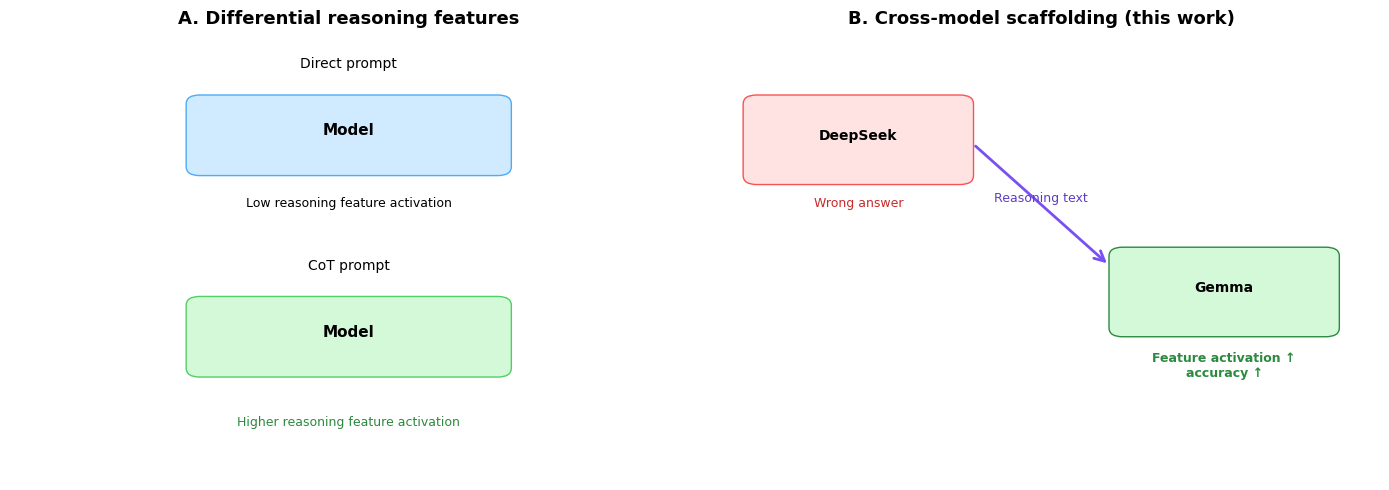

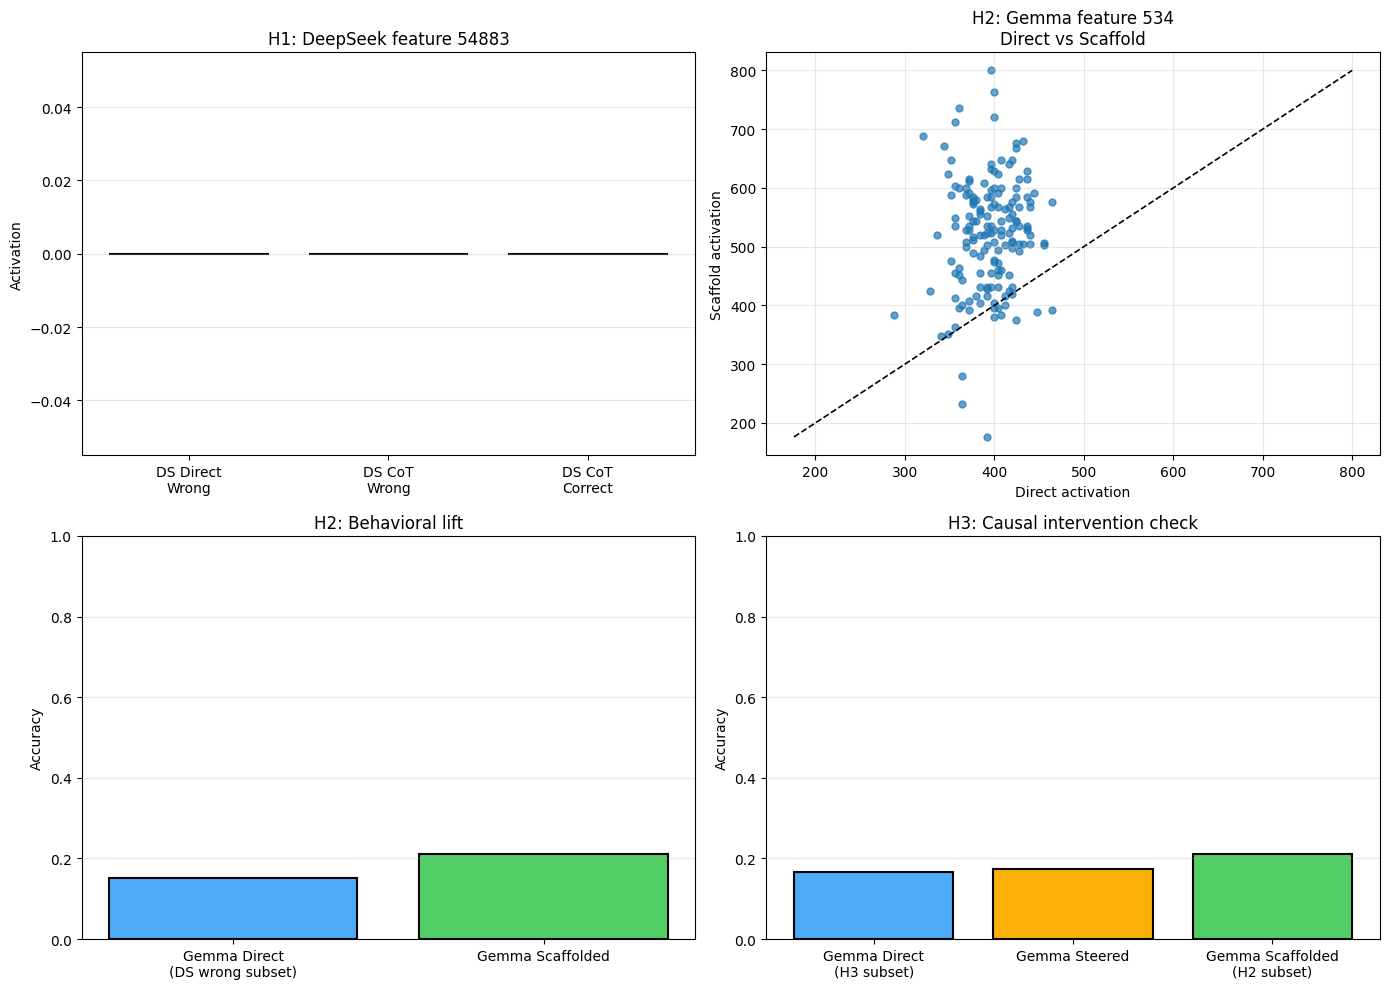

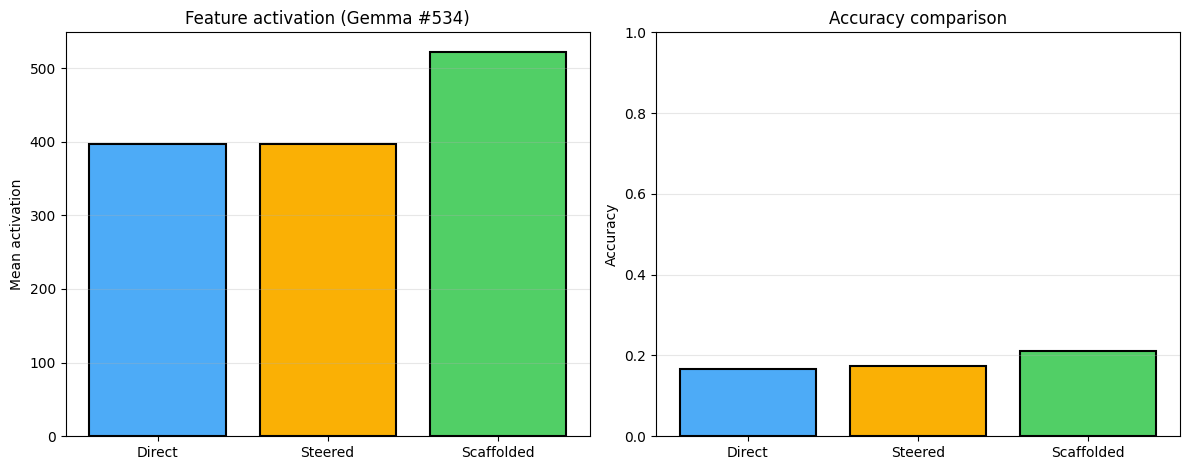

Saved figure: /root/SAELens/outputs/medical_reasoning_sae/figures/figure1_conceptual_overview.png
Saved figure: /root/SAELens/outputs/medical_reasoning_sae/figures/figure4_cross_model_scaffolding.png
Saved figure: /root/SAELens/outputs/medical_reasoning_sae/figures/figure5_steering_validation.png


In [18]:
# ---- Selected publication figures (real data): Fig1 + Fig4 + Fig5 ----
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig_dir = out_root / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)


def _safe_mean(values: list[float]) -> float:
    return float(np.mean(values)) if values else float("nan")


def _acc(records: list[ExampleRunRecord]) -> float:
    valid = [r for r in records if r.is_correct is not None]
    if not valid:
        return float("nan")
    return float(sum(1 for r in valid if r.is_correct) / len(valid))


# Figure 1: Conceptual overview
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.set_title("A. Differential reasoning features", fontsize=13, fontweight="bold")
ax1.text(0.5, 0.92, "Direct prompt", ha="center", fontsize=10)
ax1.add_patch(FancyBboxPatch((0.28, 0.70), 0.44, 0.14, boxstyle="round,pad=0.02", edgecolor="#4dabf7", facecolor="#d0ebff"))
ax1.text(0.5, 0.77, "Model", ha="center", fontsize=11, fontweight="bold")
ax1.text(0.5, 0.61, "Low reasoning feature activation", ha="center", fontsize=9)
ax1.text(0.5, 0.47, "CoT prompt", ha="center", fontsize=10)
ax1.add_patch(FancyBboxPatch((0.28, 0.25), 0.44, 0.14, boxstyle="round,pad=0.02", edgecolor="#51cf66", facecolor="#d3f9d8"))
ax1.text(0.5, 0.32, "Model", ha="center", fontsize=11, fontweight="bold")
ax1.text(0.5, 0.12, "Higher reasoning feature activation", ha="center", fontsize=9, color="#2b8a3e")
ax1.axis("off")

ax2 = axes[1]
ax2.set_title("B. Cross-model scaffolding (this work)", fontsize=13, fontweight="bold")
ax2.add_patch(FancyBboxPatch((0.08, 0.68), 0.30, 0.16, boxstyle="round,pad=0.02", edgecolor="#fa5252", facecolor="#ffe3e3"))
ax2.text(0.23, 0.76, "DeepSeek", ha="center", fontsize=10, fontweight="bold")
ax2.text(0.23, 0.61, "Wrong answer", ha="center", fontsize=9, color="#c92a2a")
arrow = FancyArrowPatch((0.40, 0.75), (0.60, 0.48), arrowstyle="->", mutation_scale=18, linewidth=2, color="#7950f2")
ax2.add_patch(arrow)
ax2.text(0.50, 0.62, "Reasoning text", ha="center", fontsize=9, color="#5f3dc4")
ax2.add_patch(FancyBboxPatch((0.62, 0.34), 0.30, 0.16, boxstyle="round,pad=0.02", edgecolor="#2b8a3e", facecolor="#d3f9d8"))
ax2.text(0.77, 0.42, "Gemma", ha="center", fontsize=10, fontweight="bold")
ax2.text(0.77, 0.23, "Feature activation ↑\naccuracy ↑", ha="center", fontsize=9, color="#2b8a3e", fontweight="bold")
ax2.axis("off")

plt.tight_layout()
fig1_path = fig_dir / "figure1_conceptual_overview.png"
plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()


# Figure 4: Cross-model scaffolding evidence (from run data)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# H1 panel: DeepSeek activation in wrong/correct cases
ax = axes[0, 0]
labels_h1 = ["DS Direct\nWrong", "DS CoT\nWrong", "DS CoT\nCorrect"]
vals_h1 = [
    _safe_mean(ds_direct_wrong_acts),
    _safe_mean(ds_cot_wrong_acts),
    _safe_mean(ds_cot_correct_acts),
]
ax.bar(labels_h1, vals_h1, color=["#fa5252", "#ff8787", "#51cf66"], edgecolor="black", linewidth=1.5)
ax.set_title(f"H1: DeepSeek feature {deepseek_primary_feature}")
ax.set_ylabel("Activation")
ax.grid(axis="y", alpha=0.3)

# H2 panel: Gemma direct vs scaffold activation
ax = axes[0, 1]
n_pairs = min(len(activation_direct), len(activation_scaffold))
if n_pairs > 0:
    ax.scatter(activation_direct[:n_pairs], activation_scaffold[:n_pairs], alpha=0.7, s=25)
    min_v = min(min(activation_direct[:n_pairs]), min(activation_scaffold[:n_pairs]))
    max_v = max(max(activation_direct[:n_pairs]), max(activation_scaffold[:n_pairs]))
    ax.plot([min_v, max_v], [min_v, max_v], linestyle="--", color="black", linewidth=1.2)
ax.set_title(f"H2: Gemma feature {gemma_primary_feature}\nDirect vs Scaffold")
ax.set_xlabel("Direct activation")
ax.set_ylabel("Scaffold activation")
ax.grid(alpha=0.3)

# H2 behavior panel: accuracy shift
ax = axes[1, 0]
acc_direct_h2 = _acc(gemma_direct_records_for_subset)
acc_scaffold_h2 = _acc(gemma_scaffold_records)
ax.bar(["Gemma Direct\n(DS wrong subset)", "Gemma Scaffolded"], [acc_direct_h2, acc_scaffold_h2],
       color=["#4dabf7", "#51cf66"], edgecolor="black", linewidth=1.5)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("H2: Behavioral lift")
ax.grid(axis="y", alpha=0.3)

# H3 panel: steering vs scaffold
ax = axes[1, 1]
acc_h3_direct = _acc(gemma_h3_direct_records) if "gemma_h3_direct_records" in globals() else float("nan")
acc_h3_steered = _acc(gemma_steered_records) if "gemma_steered_records" in globals() else float("nan")
ax.bar(["Gemma Direct\n(H3 subset)", "Gemma Steered", "Gemma Scaffolded\n(H2 subset)"],
       [acc_h3_direct, acc_h3_steered, acc_scaffold_h2],
       color=["#4dabf7", "#fab005", "#51cf66"], edgecolor="black", linewidth=1.5)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("H3: Causal intervention check")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig4_path = fig_dir / "figure4_cross_model_scaffolding.png"
plt.savefig(fig4_path, dpi=300, bbox_inches="tight")
plt.show()


# Figure 5: Steering validation (activation + accuracy)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
mean_h3_direct = _safe_mean(activation_h3_direct) if "activation_h3_direct" in globals() else float("nan")
mean_h3_steered = _safe_mean(activation_steered) if "activation_steered" in globals() else float("nan")
mean_h2_scaffold = _safe_mean(activation_scaffold)
ax.bar(["Direct", "Steered", "Scaffolded"], [mean_h3_direct, mean_h3_steered, mean_h2_scaffold],
       color=["#4dabf7", "#fab005", "#51cf66"], edgecolor="black", linewidth=1.5)
ax.set_title(f"Feature activation (Gemma #{gemma_primary_feature})")
ax.set_ylabel("Mean activation")
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.bar(["Direct", "Steered", "Scaffolded"], [acc_h3_direct, acc_h3_steered, acc_scaffold_h2],
       color=["#4dabf7", "#fab005", "#51cf66"], edgecolor="black", linewidth=1.5)
ax.set_ylim(0, 1)
ax.set_title("Accuracy comparison")
ax.set_ylabel("Accuracy")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig5_path = fig_dir / "figure5_steering_validation.png"
plt.savefig(fig5_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {fig1_path}")
print(f"Saved figure: {fig4_path}")
print(f"Saved figure: {fig5_path}")